In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv(r"C:\Users\malay\Downloads\Sales_transactions_2022_2025 cleaned & prepared.csv")



In [3]:
# 2. Basic Dataset Overview & Statistics
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Summary Statistics ---")
print(
    df[
        [
            "Customer_Age",
            "Quantity",
            "Unit_Price",
            "Discount_Percentage",
            "Sales_Amount",
            "Profit",
            "Delivery_Days",
            "Customer_Rating",
        ]
    ].describe()
)



--- Dataset Shape ---
(18001, 40)

--- Summary Statistics ---
       Customer_Age      Quantity    Unit_Price  Discount_Percentage  \
count  18001.000000  18001.000000  18000.000000         18001.000000   
mean      38.917949      2.127048    232.775236             6.254375   
std       10.658522      1.783916    294.249699             6.879826   
min        4.000000      0.000000     21.390000             0.000000   
25%       32.000000      1.000000     52.957500             0.000000   
50%       39.000000      2.000000     99.845000             5.000000   
75%       46.000000      3.000000    285.782500            10.000000   
max      112.000000     11.000000   1425.090000           110.000000   

       Sales_Amount        Profit  Delivery_Days  Customer_Rating  
count  18000.000000  18000.000000   18001.000000     18001.000000  
mean     457.449478     91.413300       2.241875         3.226043  
std      857.097154    167.856392       2.320643         1.809377  
min       16.6800

In [4]:
# Overall totals
print("\n--- Key Totals ---")
print(f"Total Sales Amount: ${df['Sales_Amount'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(
    f"Overall Profit Margin: {(df['Profit'].sum() / df['Sales_Amount'].sum()) * 100:.2f}%"
)
print(f"Total Units Sold: {df['Quantity'].sum():,}")
print(f"Total Transactions: {len(df):,}")




--- Key Totals ---
Total Sales Amount: $8,234,090.60
Total Profit: $1,645,439.40
Overall Profit Margin: 19.98%
Total Units Sold: 38,289
Total Transactions: 18,001


In [5]:
# 3. Clean Categories for Aggregations
df["Clean_Category"] = df["Product_Category"].str.title().str.strip()

# Aggregations by Product Category
print("\n--- Sales by Product Category ---")
print(
    df.groupby("Clean_Category")
    .agg({"Sales_Amount": ["sum", "mean"], "Profit": ["sum", "mean"]})
    .reset_index()
)

# Aggregations by Year
print("\n--- Sales by Year ---")
print(
    df.groupby("Order_Year")
    .agg({"Sales_Amount": "sum", "Profit": "sum", "Transaction_ID": "count"})
    .reset_index()
)




--- Sales by Product Category ---
    Clean_Category Sales_Amount                 Profit            
                            sum        mean        sum        mean
0       Appliances    584089.48  294.251627  128585.33   64.778504
1      Electronics   4922081.42  601.133539  952110.92  116.281255
2        Furniture   1986144.85  601.315425  420015.02  127.161677
3  Office Supplies    741774.85  163.964379  144728.13   31.991187
4          Unknown         0.00         NaN       0.00         NaN

--- Sales by Year ---
   Order_Year  Sales_Amount     Profit  Transaction_ID
0      2022.0    2008643.54  406576.64            4087
1      2023.0    2021352.88  401259.01            4599
2      2024.0    1905207.68  382799.40            4345
3      2025.0    2298886.50  454804.35            4969


In [6]:
# 4. Anomaly Check (Negative Profits & High Discounts)
negative_profit_count = (df["Profit"] < 0).sum()
print(
    f"\nNumber of transactions with negative profit: {negative_profit_count}"
)
print(
    "Average discount in loss-making orders:",
    df[df["Profit"] < 0]["Discount_Percentage"].mean(),
)




Number of transactions with negative profit: 231
Average discount in loss-making orders: 21.558441558441558


In [20]:
# 5. Shipping Method vs Customer Rating & Delivery Days
print("--- Customer Rating & Delivery Days by Shipping Method ---")
shipping_analysis = (
    df.groupby("Shipping_Method")
    .agg(
        Avg_Rating=("Customer_Rating", "mean"),
        Total_Orders=("Customer_Rating", "count"),
        Avg_Delivery_Days=("Delivery_Days", "mean"),
    )
    .reset_index()
)
print(shipping_analysis)



--- Customer Rating & Delivery Days by Shipping Method ---
  Shipping_Method  Avg_Rating  Total_Orders  Avg_Delivery_Days
0         Express    3.193521          2377           1.838452
1        Next Day    3.335090           949           1.359326
2          Pickup    3.263150          6939           0.000000
3        Standard    3.189787          7735           4.485585
4        Unknown     0.000000             1           0.000000


In [21]:
# 6. Return Reasons Breakdown
print("\n--- Return Reasons Breakdown ---")
return_reasons = df["Return_Reason"].value_counts().reset_index()
return_reasons.columns = ["Return_Reason", "Count"]
print(return_reasons)




--- Return Reasons Breakdown ---
   Return_Reason  Count
0   Not Returned  16128
1  Late Delivery    331
2     Wrong Item    317
3        Damaged    312
4          Other    311
5      Defective    302
6   Changed Mind    300


In [22]:
# 7. Performance by Customer Segment
print("\n--- Performance by Customer Segment ---")
segment_analysis = (
    df.groupby("Customer_Segment")
    .agg(
        Total_Sales=("Sales_Amount", "sum"),
        Avg_Sales=("Sales_Amount", "mean"),
        Total_Profit=("Profit", "sum"),
        Avg_Profit=("Profit", "mean"),
        Total_Quantity=("Quantity", "sum"),
    )
    .reset_index()
)
print(segment_analysis)





--- Performance by Customer Segment ---
     Customer_Segment  Total_Sales   Avg_Sales  Total_Profit  Avg_Profit  \
0            Consumer   3666739.39  456.800721     737660.17   91.897368   
1           Corporate    942132.17  450.996730     175673.11   84.094356   
2        New Customer    708173.63  488.395607     141279.15   97.433897   
3             Premium    379818.46  475.367284      79119.14   99.022703   
4  Returning Customer   1115273.90  452.260300     224109.25   90.879663   
5      Small Business   1421953.05  448.707179     287598.58   90.753733   
6             Unknown         0.00         NaN          0.00         NaN   

   Total_Quantity  
0           17063  
1            4433  
2            3082  
3            1698  
4            5413  
5            6600  
6               0  


In [23]:
# 8. Impact of Promotion Codes
print("\n--- Impact of Promotion Codes ---")
promo_analysis = (
    df.groupby("Promotion_Code")
    .agg(
        Avg_Sales=("Sales_Amount", "mean"),
        Avg_Profit=("Profit", "mean"),
        Total_Transactions=("Transaction_ID", "count"),
    )
    .reset_index()
)
print(promo_analysis)


--- Impact of Promotion Codes ---
   Promotion_Code   Avg_Sales  Avg_Profit  Total_Transactions
0       BACK2WORK  490.419289   95.606219                 886
1   BLACKFRIDAY25  459.058853   93.129211                1229
2           CORP5  416.904286   82.981874                 539
3     HALLOWEEN15  461.761273   97.010964                 550
4       HOLIDAY20  454.981583   89.912199                1396
5           MOM15  453.509137   91.077003                 684
6         Not Avl  455.167158   90.976348                9712
7          SAVE10  478.504407   98.322177                 767
8        SPRING15  431.115090   86.841066                 835
9        SUMMER10  492.014086   96.634889                 859
10    VALENTINE20  444.095046   84.497366                 543


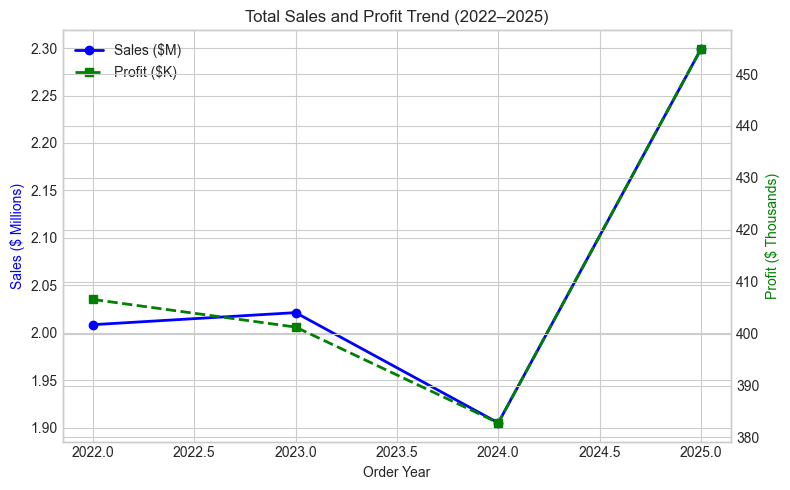

In [10]:
# 9. Visualizations Generation

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
# Chart 1: Yearly Sales and Profit Trend
yearly = (
    df.groupby("Order_Year")[["Sales_Amount", "Profit"]]
    .sum()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Sales line
sales_line, = ax1.plot(
    yearly["Order_Year"],
    yearly["Sales_Amount"] / 1e6,
    "bo-",
    linewidth=2,
    label="Sales ($M)"
)
ax1.set_xlabel("Order Year")
ax1.set_ylabel("Sales ($ Millions)", color="b")

# Profit line (secondary axis)
ax2 = ax1.twinx()
profit_line, = ax2.plot(
    yearly["Order_Year"],
    yearly["Profit"] / 1e3,
    "gs--",
    linewidth=2,
    label="Profit ($K)"
)
ax2.set_ylabel("Profit ($ Thousands)", color="g")

# Combine legends from both axes
lines = [sales_line, profit_line]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Total Sales and Profit Trend (2022–2025)")
plt.tight_layout()
plt.show()




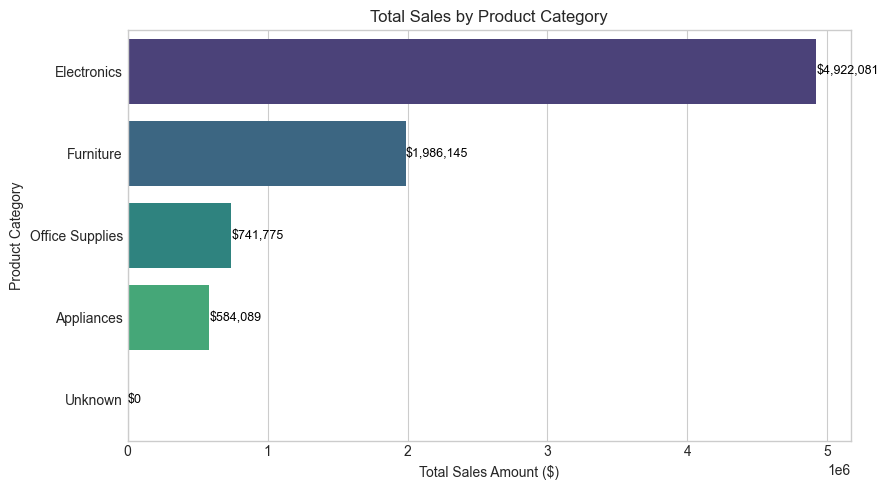

In [19]:
# Chart 2: Sales by Product Category

plt.style.use("seaborn-v0_8-whitegrid")

cat_sales = (
    df.groupby("Clean_Category")["Sales_Amount"]
    .sum()
    .reset_index()
    .sort_values(by="Sales_Amount", ascending=False)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=cat_sales,
    x="Sales_Amount",
    y="Clean_Category",
    hue="Clean_Category",   # fixes palette warning
    palette="viridis",
    legend=False
)

# Add data labels to each bar
for i, v in enumerate(cat_sales["Sales_Amount"]):
    ax.text(
        v, i, f"${v:,.0f}",   # formatted with commas
        va="center", ha="left",
        fontsize=9, color="black"
    )

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales Amount ($)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()





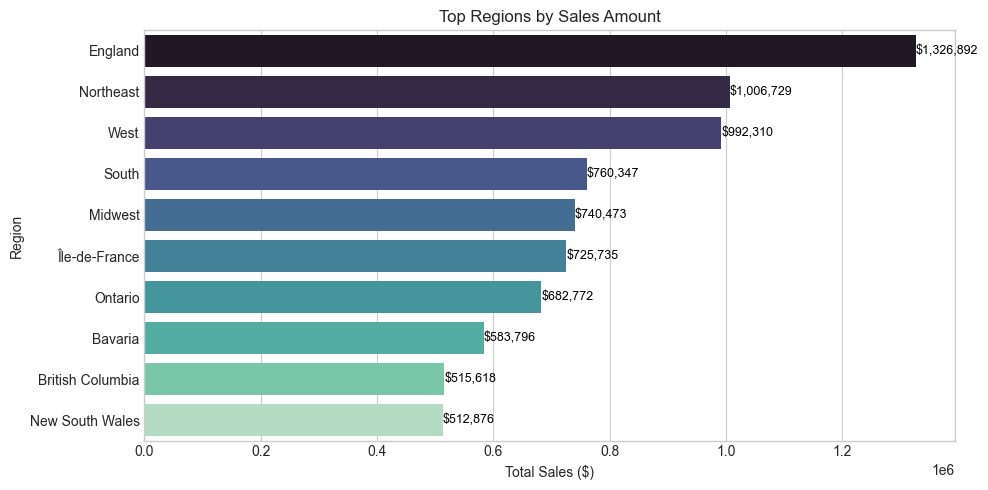

In [14]:
# Chart 3: Regional Sales Distribution


plt.style.use("seaborn-v0_8-whitegrid")

reg_sales = (
    df.groupby("Region")["Sales_Amount"]
    .sum()
    .reset_index()
    .sort_values(by="Sales_Amount", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=reg_sales,
    x="Sales_Amount",
    y="Region",
    hue="Region",       # fixes palette warning
    palette="mako",
    legend=False
)

# Add data labels
for i, v in enumerate(reg_sales["Sales_Amount"]):
    ax.text(
        v, i, f"${v:,.0f}",   # formatted with commas
        va="center", ha="left",
        fontsize=9, color="black"
    )

plt.title("Top Regions by Sales Amount")
plt.xlabel("Total Sales ($)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()




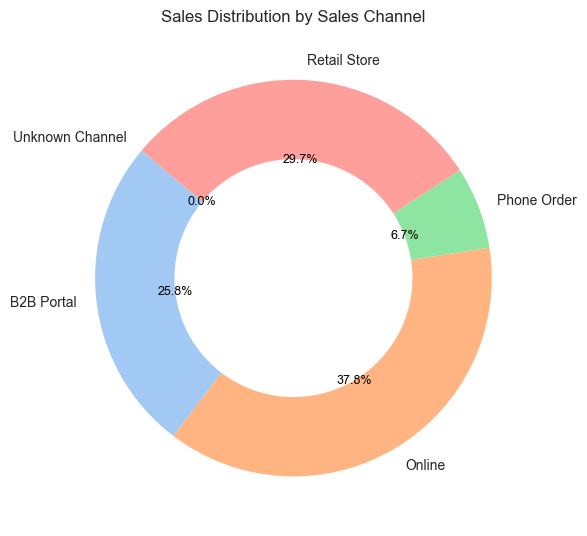

In [17]:
# Chart 4: Sales Channel Breakdown (Donut/Pie Chart)


plt.style.use("seaborn-v0_8-whitegrid")

channel_sales = df.groupby("Sales_Channel")["Sales_Amount"].sum().reset_index()

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    channel_sales["Sales_Amount"],
    labels=channel_sales["Sales_Channel"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
    wedgeprops=dict(width=0.4)   # makes it a donut chart
)

# Improve label readability
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(9)

plt.title("Sales Distribution by Sales Channel")
plt.tight_layout()
plt.show()


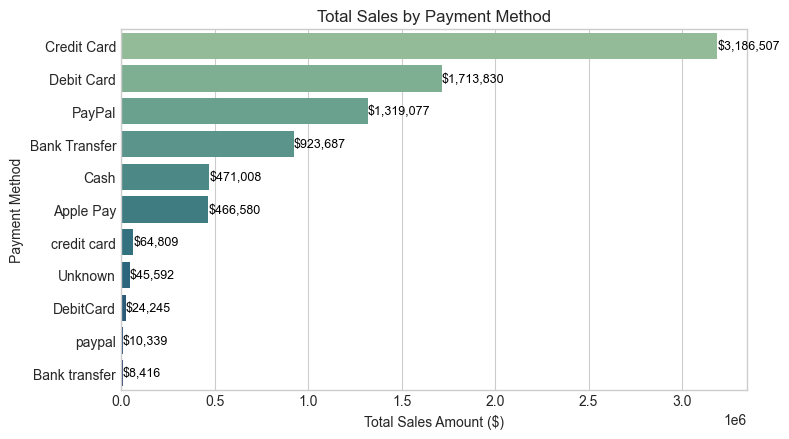


All scripts and charts executed and saved successfully!


In [18]:


plt.style.use("seaborn-v0_8-whitegrid")

payment_sales = (
    df.groupby("Payment_Method")["Sales_Amount"]
    .sum()
    .reset_index()
    .sort_values(by="Sales_Amount", ascending=False)
)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=payment_sales,
    x="Sales_Amount",
    y="Payment_Method",
    hue="Payment_Method",   # fixes palette warning
    palette="crest",
    legend=False
)

# Add data labels
for i, v in enumerate(payment_sales["Sales_Amount"]):
    ax.text(
        v, i, f"${v:,.0f}",   # formatted with commas
        va="center", ha="left",
        fontsize=9, color="black"
    )

plt.title("Total Sales by Payment Method")
plt.xlabel("Total Sales Amount ($)")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()